**PREDICTIVE QUALITY CONTROL OF MACHINED SHAFTS**

In [ ]:
#Installing all necessary libraries

# Core
import numpy as np
import matplotlib.pyplot as plt

# Signal Processing
from scipy.stats import kurtosis, skew
from numpy.fft import fft
import pywt


# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# DL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import time

# Visualization
import seaborn as sns

print("All libraries loaded!")
print(f"   TensorFlow version: {tf.__version__}")

All libraries loaded!
   TensorFlow version: 2.19.0


 Please upload your .npz file.


Saving CWRU_48k_load_1_CNN_data.npz to CWRU_48k_load_1_CNN_data (1).npz

 File uploaded: CWRU_48k_load_1_CNN_data (1).npz
 DATASET ANALYSIS REPORT:
  File name      : CWRU_48k_load_1_CNN_data (1).npz
  Keys inside    : ['data', 'labels']
  Raw shape      : (4600, 32, 32)
  Flattened      : (4600, 1024)
  Labels shape   : (4600,)
  Data type      : float64
  Min value      : -6.2926
  Max value      : 6.8259

  Total classes  : 10
  Balanced?      : YES
  Domain         :  TIME DOMAIN

  Class Distribution:
    Ball_007   → 460 samples  ███████████████████████
    Ball_014   → 460 samples  ███████████████████████
    Ball_021   → 460 samples  ███████████████████████
    IR_007     → 460 samples  ███████████████████████
    IR_014     → 460 samples  ███████████████████████
    IR_021     → 460 samples  ███████████████████████
    Normal     → 460 samples  ███████████████████████
    OR_007     → 460 samples  ███████████████████████
    OR_014     → 460 samples  ███████████████████████
  

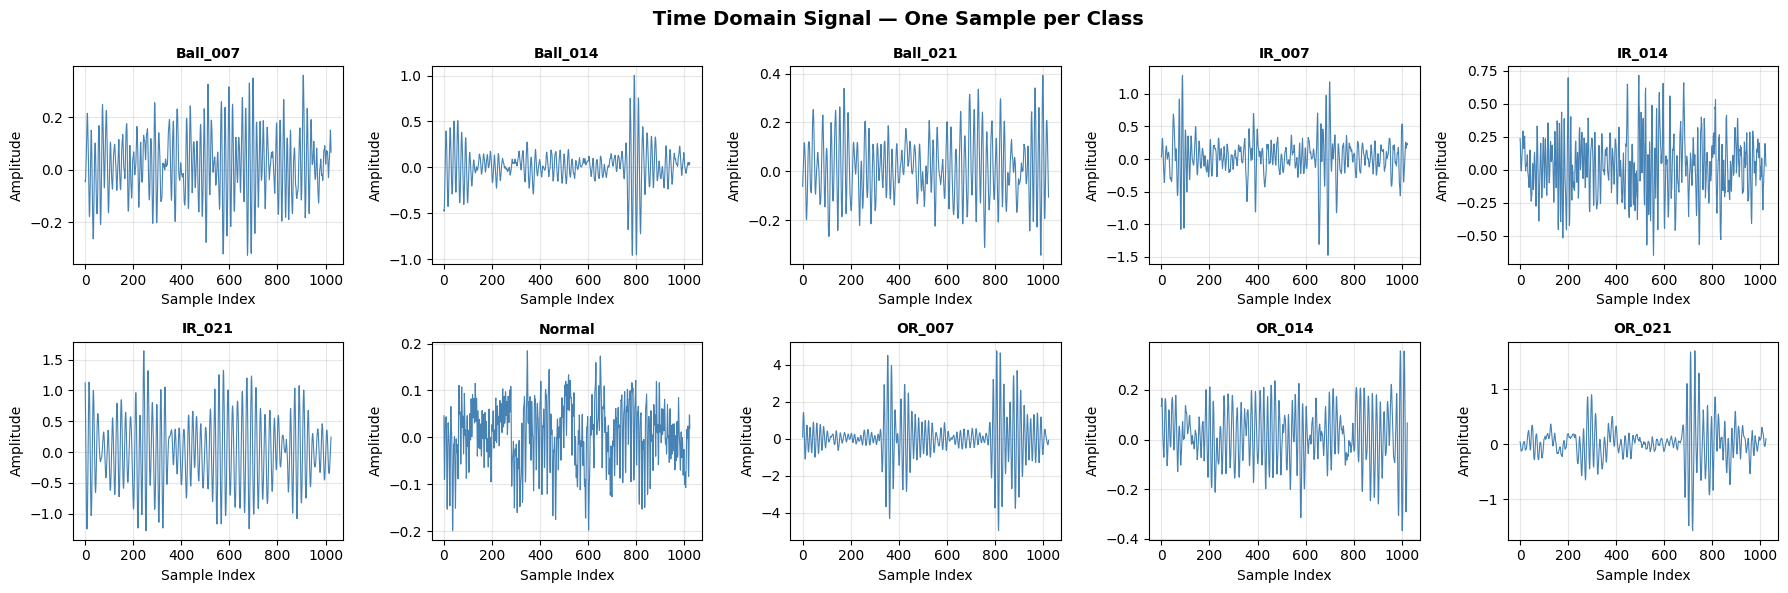

In [ ]:
from google.colab import files

#  Upload
print(" Please upload your .npz file.")
uploaded = files.upload()

# Auto detect filename
filename = list(uploaded.keys())[0]
print(f"\n File uploaded: {filename}")

# Load
data  = np.load(filename, allow_pickle=True)
X_raw = data['data']
y     = data['labels']
X     = X_raw.reshape(len(X_raw), -1)

#  Analysis Report
classes, counts = np.unique(y, return_counts=True)

print(" DATASET ANALYSIS REPORT:")

print(f"  File name      : {filename}")
print(f"  Keys inside    : {list(data.keys())}")
print(f"  Raw shape      : {X_raw.shape}")
print(f"  Flattened      : {X.shape}")
print(f"  Labels shape   : {y.shape}")
print(f"  Data type      : {X.dtype}")
print(f"  Min value      : {X.min():.4f}")
print(f"  Max value      : {X.max():.4f}")
print(f"\n  Total classes  : {len(classes)}")
print(f"  Balanced?      : {'YES' if len(set(counts))==1 else 'NO'}")
print(f"  Domain         :  TIME DOMAIN")
print("\n  Class Distribution:")
for cls, cnt in zip(classes, counts):
    bar = '█' * (cnt // 20)
    print(f"    {cls:10s} → {cnt} samples  {bar}")
print("=" * 45)

# Plot
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, cls in zip(axes.flatten(), classes):
    idx = np.where(y == cls)[0][0]
    ax.plot(X[idx], linewidth=0.8, color='steelblue')
    ax.set_title(cls, fontsize=10, fontweight='bold')
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

plt.suptitle(" Time Domain Signal — One Sample per Class",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**The 32x32 data is raw vibration signal segments so it is in TIME DOMAIN**

In [ ]:
#Extrating Features

def extract_time_features(signal):
    rms         = np.sqrt(np.mean(signal**2))
    peak        = np.max(np.abs(signal))

    features = [
        np.mean(signal),                              # 1. Mean
        np.std(signal),                               # 2. Std Dev
        rms,                                          # 3. RMS
        kurtosis(signal),                             # 4. Kurtosis
        skew(signal),                                 # 5. Skewness
        peak,                                         # 6. Peak
        peak / (rms + 1e-9),                          # 7. Crest Factor
        np.mean(np.abs(signal)),                      # 8. Mean Absolute Value
        np.ptp(signal),                               # 9. Peak-to-Peak
        np.var(signal),                               # 10. Variance
    ]
    return features

# Extract for all 4600 samples
X_time_feat = np.array([extract_time_features(sig) for sig in X])

print("Time Domain Features Extracted!")
print(f"   Feature matrix shape : {X_time_feat.shape}")
print(f"   → {X_time_feat.shape[0]} samples × {X_time_feat.shape[1]} features")
print("\n   Features Used:")
names = ['Mean','Std Dev','RMS','Kurtosis','Skewness',
         'Peak','Crest Factor','MAV','Peak-to-Peak','Variance']
for i, n in enumerate(names):
    print(f"    {i+1:2d}. {n}")

Time Domain Features Extracted!
   Feature matrix shape : (4600, 10)
   → 4600 samples × 10 features

   Features Used:
     1. Mean
     2. Std Dev
     3. RMS
     4. Kurtosis
     5. Skewness
     6. Peak
     7. Crest Factor
     8. MAV
     9. Peak-to-Peak
    10. Variance


In [ ]:
# Using WPT to break signal into smaller frequency bands for better analysis

def apply_wpt(signal, wavelet='db4', level=3):
    wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, maxlevel=level)
    nodes = [node.path for node in wp.get_level(level, 'natural')]
    feats = []
    for node in nodes:
        coeff = wp[node].data
        feats += [
            np.sqrt(np.mean(coeff**2)),  # RMS
            kurtosis(coeff),             # Kurtosis
            np.max(np.abs(coeff)),       # Peak
        ]
    return feats

X_wpt = np.array([apply_wpt(sig) for sig in X])

# Combine with time features
X_final_time = np.hstack([X_time_feat, X_wpt])

print(f"WPT Done!")
print(f"   WPT features shape : {X_wpt.shape}")
print(f"   Time features      : {X_time_feat.shape[1]}")
print(f"   WPT features       : {X_wpt.shape[1]}")
print(f"  Final combined  : {X_final_time.shape}")

WPT Done!
   WPT features shape : (4600, 24)
   Time features      : 10
   WPT features       : 24
  Final combined  : (4600, 34)


In [ ]:
# Preparing label encoding & split & scaling data

# Step 1: Encode labels (text → numbers)
le = LabelEncoder()
y_enc = le.fit_transform(y)
# Ball_007=0, Ball_014=1 ... Normal=6 etc.

# Step 2: Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_final_time, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc        # keeps class balance
)

# Step 3: Scale features (very important for DL!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Step 4: One-hot encode for DL model
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print("Data Preparation Done!")
print(f"   Train samples : {X_train.shape}")
print(f"   Test samples  : {X_test.shape}")
print(f"   Classes       : {list(le.classes_)}")

Data Preparation Done!
   Train samples : (3680, 34)
   Test samples  : (920, 34)
   Classes       : [np.str_('Ball_007'), np.str_('Ball_014'), np.str_('Ball_021'), np.str_('IR_007'), np.str_('IR_014'), np.str_('IR_021'), np.str_('Normal'), np.str_('OR_007'), np.str_('OR_014'), np.str_('OR_021')]


In [ ]:
 # Applying ML Models

# Random Forest
print(" Training Random Forest.")
t1 = time.time()
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f" Random Forest  → Accuracy: {rf_acc*100:.2f}%  | Time: {time.time()-t1:.1f}s")

# SVM
print("\n Training SVM...")
t2 = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc  = accuracy_score(y_test, svm_pred)
print(f" SVM            → Accuracy: {svm_acc*100:.2f}%  | Time: {time.time()-t2:.1f}s")

print(f"  RF  Accuracy : {rf_acc*100:.2f}%")
print(f"  SVM Accuracy : {svm_acc*100:.2f}%")


 Training Random Forest.
 Random Forest  → Accuracy: 96.63%  | Time: 3.2s

 Training SVM...
 SVM            → Accuracy: 96.52%  | Time: 0.2s
  RF  Accuracy : 96.63%
  SVM Accuracy : 96.52%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,354 (317.79 KB)

 Trainable params: 80,330 (313.79 KB)

 Non-trainable params: 1,024 (4.00 KB)


 Training DL Model...
Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6450 - loss: 1.0383 - val_accuracy: 0.8465 - val_loss: 0.8206
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8353 - loss: 0.4826 - val_accuracy: 0.8886 - val_loss: 0.3643
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8631 - loss: 0.4044 - val_accuracy: 0.9348 - val_loss: 0.2415
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8760 - loss: 0.3404 - val_accuracy: 0.9389 - val_loss: 0.2071
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8906 - loss: 0.3095 - val_accuracy: 0.9361 - val_loss: 0.1892
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9056 - loss: 0.2663 - val_accuracy: 0.9511 - val_loss: 0.1468
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9079 - loss: 0.2584 - val_accuracy: 0.9538 - val_loss: 0.1418
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9181 - loss: 0.2292 - 

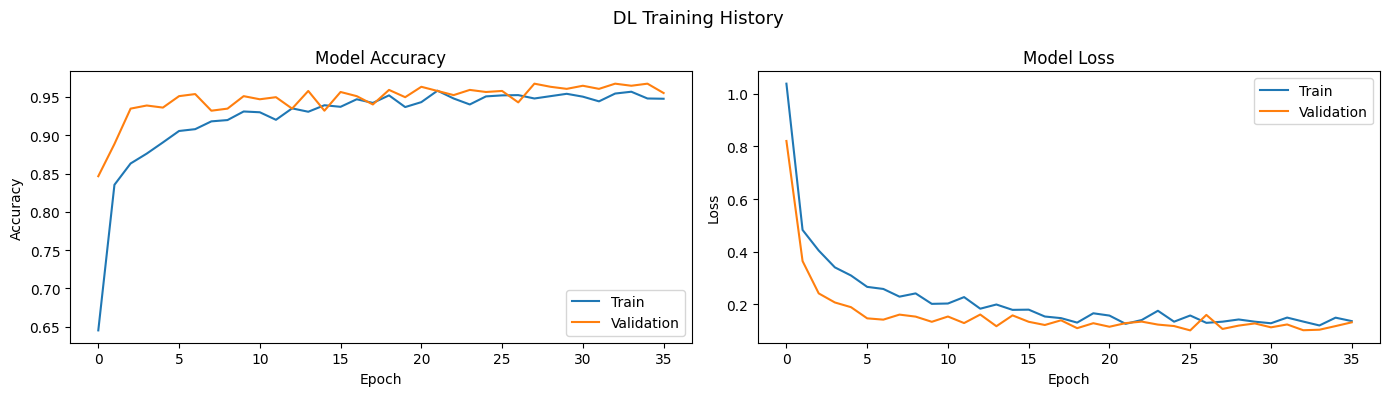

In [ ]:
# Using DL Model ( MLP NEURAL NETWORK)

#  Build Model
model = Sequential([
    # Input Layer
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 1
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden Layer 3
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output Layer (10 classes)
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

#  Train
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True)
print("\n Training DL Model...")
t = time.time()
history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
dl_loss, dl_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n DL Model → Accuracy: {dl_acc*100:.2f}% | Time: {time.time()-t:.1f}s")

# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],    label='Train')
axes[0].plot(history.history['val_accuracy'],label='Validation')
axes[0].set_title('Model Accuracy'); axes[0].legend()
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')

axes[1].plot(history.history['loss'],    label='Train')
axes[1].plot(history.history['val_loss'],label='Validation')
axes[1].set_title('Model Loss'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

plt.suptitle(' DL Training History', fontsize=13)
plt.tight_layout()
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


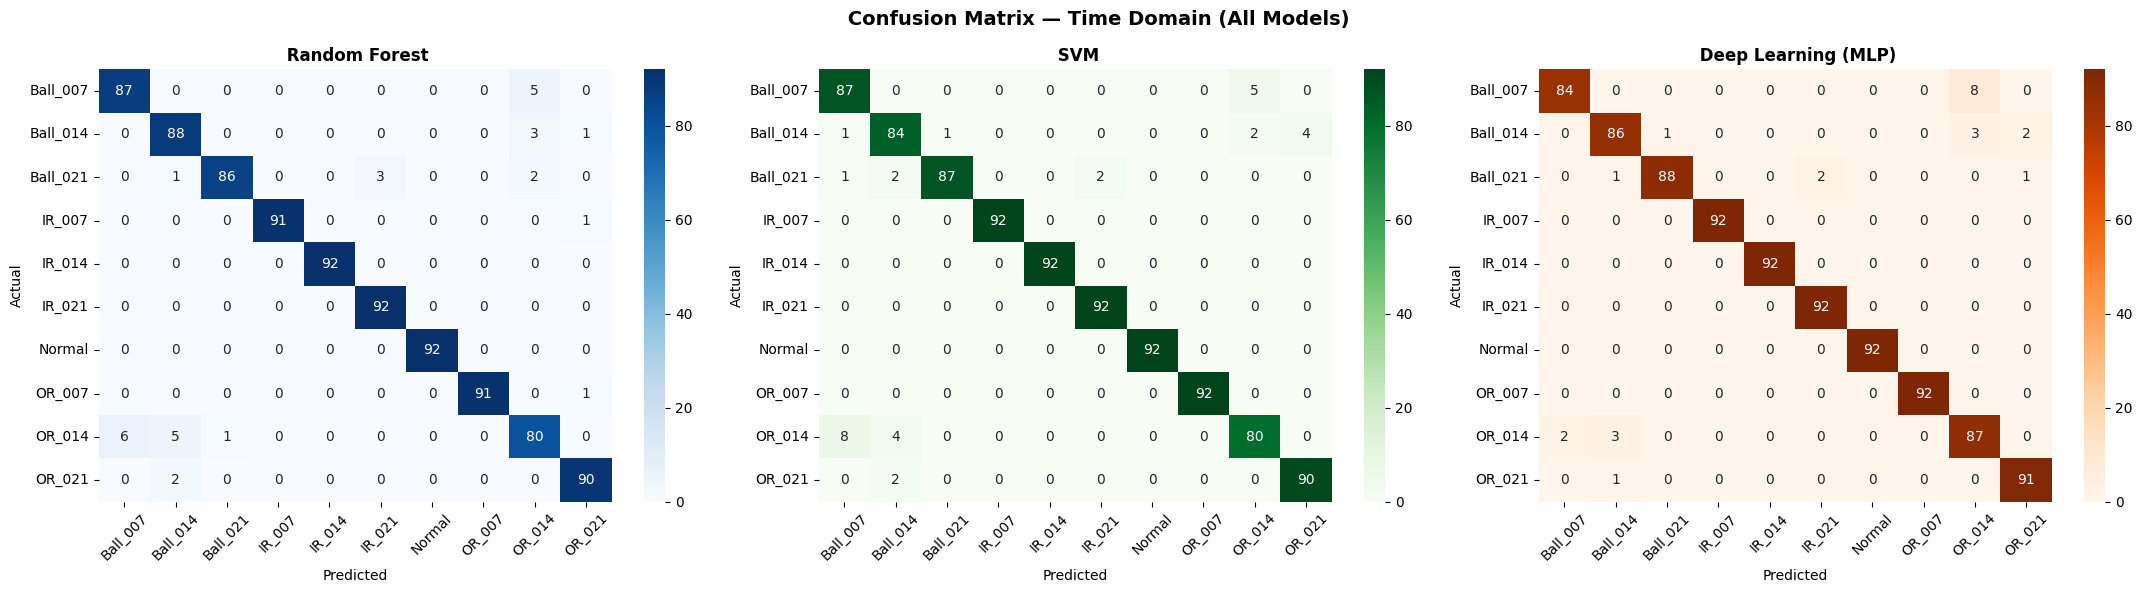


      TIME DOMAIN RESULTS
  Random Forest : 96.63%
  SVM           : 96.52%
  Deep Learning : 97.39%

  Best Model : Deep Learning (97.39%)


In [ ]:
# Heatmap and Confusion Matrices

# Get Predictions
rf_pred   = rf.predict(X_test)
svm_pred  = svm.predict(X_test)
dl_pred   = np.argmax(model.predict(X_test), axis=1)

# Confusion Matrices
cm_rf  = confusion_matrix(y_test, rf_pred)
cm_svm = confusion_matrix(y_test, svm_pred)
cm_dl  = confusion_matrix(y_test, dl_pred)

# Plot All 3
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, cm, title, cmap in zip(
    axes,
    [cm_rf, cm_svm, cm_dl],
    ['Random Forest', 'SVM', 'Deep Learning (MLP)'],
    ['Blues', 'Greens', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=cmap,
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                ax=ax)
    ax.set_title(f' {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(' Confusion Matrix — Time Domain (All Models)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print Accuracy Summary
print("\n" + "="*40)
print("      TIME DOMAIN RESULTS")
print("="*40)
print(f"  Random Forest : {rf_acc*100:.2f}%")
print(f"  SVM           : {svm_acc*100:.2f}%")
print(f"  Deep Learning : {dl_acc*100:.2f}%")
print("="*40)

# Best Model
scores = {'Random Forest': rf_acc, 'SVM': svm_acc, 'Deep Learning': dl_acc}
best   = max(scores, key=scores.get)
print(f"\n  Best Model : {best} ({scores[best]*100:.2f}%)")

**Now converting the data from TIME DOMAIN into FREQUENCY DOMAIN**


 FFT Done!
   Time Domain shape : (4600, 1024)
   Freq Domain shape : (4600, 512)


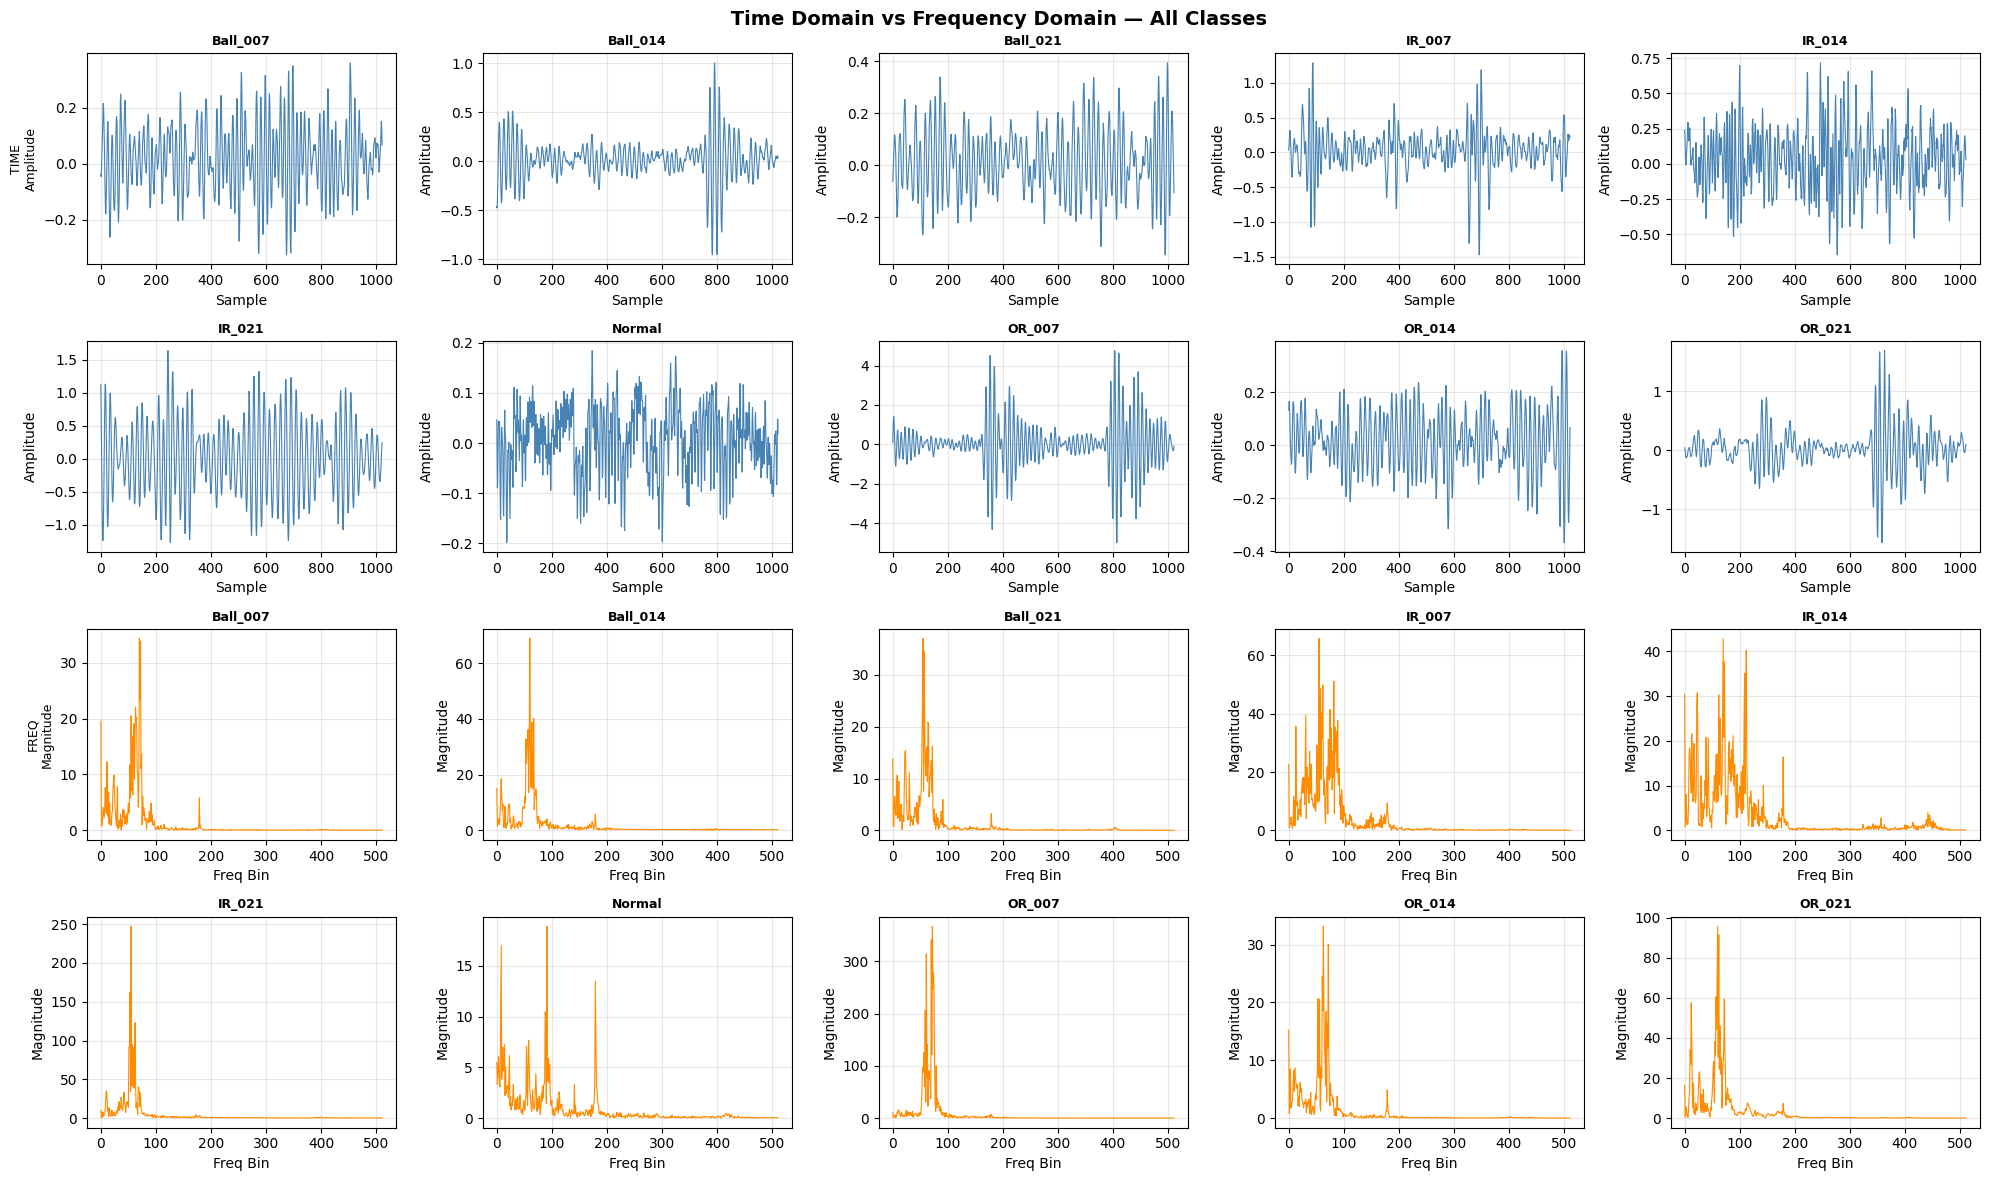

In [ ]:
# FFT Conversion
X_fft = np.abs(fft(X))[:, :512]

print(" FFT Done!")
print(f"   Time Domain shape : {X.shape}")
print(f"   Freq Domain shape : {X_fft.shape}")

#  Plot Fixed
fig, axes = plt.subplots(4, 5, figsize=(20, 12))

for i, cls in enumerate(classes):
    idx = np.where(y == cls)[0][0]

    # Row 0,1 = Time Domain (first 5 and second 5)
    row = 0 if i < 5 else 1
    col = i if i < 5 else i - 5
    axes[row, col].plot(X[idx], color='steelblue', linewidth=0.8)
    axes[row, col].set_title(cls, fontsize=9, fontweight='bold')
    axes[row, col].set_xlabel("Sample")
    axes[row, col].set_ylabel("Amplitude")
    axes[row, col].grid(alpha=0.3)

    # Row 2,3 = Frequency Domain
    row2 = 2 if i < 5 else 3
    axes[row2, col].plot(X_fft[idx], color='darkorange', linewidth=0.8)
    axes[row2, col].set_title(cls, fontsize=9, fontweight='bold')
    axes[row2, col].set_xlabel("Freq Bin")
    axes[row2, col].set_ylabel("Magnitude")
    axes[row2, col].grid(alpha=0.3)

# Labels
axes[0,0].set_ylabel("TIME\nAmplitude", fontsize=9)
axes[2,0].set_ylabel("FREQ\nMagnitude", fontsize=9)

plt.suptitle(" Time Domain vs Frequency Domain — All Classes",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Frequency domain Feature extraction

def extract_freq_features(spectrum):
    total_power = np.sum(spectrum**2)
    freqs       = np.arange(len(spectrum))
    mean_freq   = np.sum(freqs * spectrum**2) / (total_power + 1e-9)

    features = [
        np.mean(spectrum),                    # 1. Mean magnitude
        np.std(spectrum),                     # 2. Std of spectrum
        np.max(spectrum),                     # 3. Peak magnitude
        np.argmax(spectrum),                  # 4. Dominant frequency
        total_power,                          # 5. Total power
        mean_freq,                            # 6. Mean frequency
        np.sum((freqs - mean_freq)**2 *
               spectrum**2)/(total_power+1e-9), # 7. Freq variance
        kurtosis(spectrum),                   # 8. Spectral kurtosis
        skew(spectrum),                       # 9. Spectral skewness
        np.median(spectrum),                  # 10. Median magnitude
    ]
    return features

# Extract for all 4600 samples
X_freq_feat = np.array([extract_freq_features(s) for s in X_fft])

print(" Frequency Features Extracted!")
print(f"   Feature matrix shape : {X_freq_feat.shape}")
print(f"   → {X_freq_feat.shape[0]} samples × {X_freq_feat.shape[1]} features")
print("\n   Features Used:")
names = ['Mean Magnitude', 'Std Spectrum', 'Peak Magnitude',
         'Dominant Frequency', 'Total Power', 'Mean Frequency',
         'Freq Variance', 'Spectral Kurtosis',
         'Spectral Skewness', 'Median Magnitude']
for i, n in enumerate(names):
    print(f"    {i+1:2d}. {n}")

 Frequency Features Extracted!
   Feature matrix shape : (4600, 10)
   → 4600 samples × 10 features

   Features Used:
     1. Mean Magnitude
     2. Std Spectrum
     3. Peak Magnitude
     4. Dominant Frequency
     5. Total Power
     6. Mean Frequency
     7. Freq Variance
     8. Spectral Kurtosis
     9. Spectral Skewness
    10. Median Magnitude


In [ ]:
# Using WPT to break signal into smaller frequency bands for better analysis

def apply_wpt_freq(signal, wavelet='db4', level=3):
    wp    = pywt.WaveletPacket(data=signal, wavelet=wavelet, maxlevel=level)
    nodes = [node.path for node in wp.get_level(level, 'natural')]
    feats = []
    for node in nodes:
        coeff = wp[node].data
        feats += [
            np.sqrt(np.mean(coeff**2)),  # RMS
            kurtosis(coeff),             # Kurtosis
            np.max(np.abs(coeff)),       # Peak
        ]
    return feats

# Apply WPT on frequency signals
print(" Applying WPT on Frequency Domain.")
X_wpt_freq = np.array([apply_wpt_freq(sig) for sig in X_fft])

# Combine freq features + WPT features
X_final_freq = np.hstack([X_freq_feat, X_wpt_freq])

print(f" WPT Done!")
print(f"   Freq features      : {X_freq_feat.shape[1]}")
print(f"   WPT features       : {X_wpt_freq.shape[1]}")
print(f"    Final combined  : {X_final_freq.shape}")

 Applying WPT on Frequency Domain.
 WPT Done!
   Freq features      : 10
   WPT features       : 24
    Final combined  : (4600, 34)


In [ ]:
# Preparing Frequency Data ( Encode + Split + Scale)

# Step 1: Encode labels (already done but doing fresh for freq)
le_freq   = LabelEncoder()
y_enc_freq = le_freq.fit_transform(y)

# Step 2: Train/Test Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final_freq, y_enc_freq,
    test_size=0.2,
    random_state=42,
    stratify=y_enc_freq
)

# Step 3: Scale
scaler_f   = StandardScaler()
X_train_f  = scaler_f.fit_transform(X_train_f)
X_test_f   = scaler_f.transform(X_test_f)

# Step 4: One-hot for DL
y_train_f_cat = to_categorical(y_train_f, num_classes=10)
y_test_f_cat  = to_categorical(y_test_f,  num_classes=10)

print(" Frequency Data Ready!")
print(f"   Train shape : {X_train_f.shape}")
print(f"   Test shape  : {X_test_f.shape}")
print(f"   Classes     : {list(le_freq.classes_)}")

 Frequency Data Ready!
   Train shape : (3680, 34)
   Test shape  : (920, 34)
   Classes     : [np.str_('Ball_007'), np.str_('Ball_014'), np.str_('Ball_021'), np.str_('IR_007'), np.str_('IR_014'), np.str_('IR_021'), np.str_('Normal'), np.str_('OR_007'), np.str_('OR_014'), np.str_('OR_021')]


In [ ]:
# Applying ML Models

#  Random Forest
print("Training Random Forest.")
t1  = time.time()
rf_f = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_f.fit(X_train_f, y_train_f)
rf_f_pred = rf_f.predict(X_test_f)
rf_f_acc  = accuracy_score(y_test_f, rf_f_pred)
print(f" Random Forest → Accuracy: {rf_f_acc*100:.2f}% | Time: {time.time()-t1:.1f}s")

# SVM
print("\n⏳ Training SVM...")
t2   = time.time()
svm_f = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_f.fit(X_train_f, y_train_f)
svm_f_pred = svm_f.predict(X_test_f)
svm_f_acc  = accuracy_score(y_test_f, svm_f_pred)
print(f" SVM           → Accuracy: {svm_f_acc*100:.2f}% | Time: {time.time()-t2:.1f}s")

print("\n" + "="*40)
print("    FREQUENCY DOMAIN — ML RESULTS")
print("="*40)
print(f"   Random Forest : {rf_f_acc*100:.2f}%")
print(f"   SVM           : {svm_f_acc*100:.2f}%")
print("="*40)

Training Random Forest.
 Random Forest → Accuracy: 96.74% | Time: 4.7s

⏳ Training SVM...
 SVM           → Accuracy: 96.09% | Time: 0.2s

    FREQUENCY DOMAIN — ML RESULTS
   Random Forest : 96.74%
   SVM           : 96.09%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,354 (317.79 KB)

 Trainable params: 80,330 (313.79 KB)

 Non-trainable params: 1,024 (4.00 KB)


 Training DL Model on Frequency Domain.
Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6060 - loss: 1.1331 - val_accuracy: 0.8166 - val_loss: 0.7956
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7986 - loss: 0.5488 - val_accuracy: 0.8777 - val_loss: 0.3777
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8410 - loss: 0.4281 - val_accuracy: 0.9130 - val_loss: 0.2469
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8668 - loss: 0.3576 - val_accuracy: 0.9185 - val_loss: 0.1998
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8791 - loss: 0.3265 - val_accuracy: 0.9416 - val_loss: 0.1618
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8974 - loss: 0.2952 - val_accuracy: 0.9239 - val_loss: 0.1635
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8889 - loss: 0.2917 - val_accuracy: 0.9293 - val_loss: 0.1691
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9018

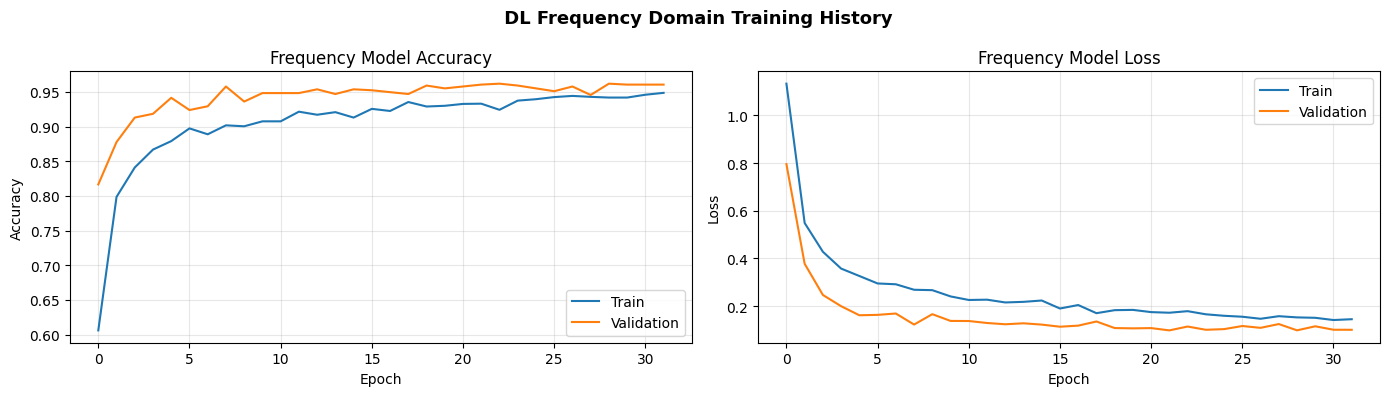


    FREQUENCY DOMAIN RESULTS
   Random Forest : 96.74%
   SVM           : 96.09%
   Deep Learning : 95.43%

 Best Model : Random Forest (96.74%)


In [ ]:
# Using DL Model ( MLP NEURAL NETWORK)

#  Build DL Model
model_freq = Sequential([
    # Input Layer
    Dense(128, activation='relu', input_shape=(X_train_f.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 1
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden Layer 3
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output Layer
    Dense(10, activation='softmax')
])

model_freq.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_freq.summary()

# Train
early_stop_f = EarlyStopping(monitor='val_loss', patience=10,
                              restore_best_weights=True)
print("\n Training DL Model on Frequency Domain.")
t = time.time()
history_freq = model_freq.fit(
    X_train_f, y_train_f_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_f],
    verbose=1
)

#  Evaluate
dl_f_loss, dl_f_acc = model_freq.evaluate(X_test_f, y_test_f_cat, verbose=0)
print(f"\n DL Freq Model → Accuracy: {dl_f_acc*100:.2f}% | Time: {time.time()-t:.1f}s")

# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_freq.history['accuracy'],     label='Train')
axes[0].plot(history_freq.history['val_accuracy'], label='Validation')
axes[0].set_title('Frequency Model Accuracy')
axes[0].legend()
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(alpha=0.3)

axes[1].plot(history_freq.history['loss'],     label='Train')
axes[1].plot(history_freq.history['val_loss'], label='Validation')
axes[1].set_title('Frequency Model Loss')
axes[1].legend()
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)

plt.suptitle(' DL Frequency Domain Training History',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#  Summary
print("\n" + "="*40)
print("    FREQUENCY DOMAIN RESULTS")
print("="*40)
print(f"   Random Forest : {rf_f_acc*100:.2f}%")
print(f"   SVM           : {svm_f_acc*100:.2f}%")
print(f"   Deep Learning : {dl_f_acc*100:.2f}%")
print("="*40)
scores_f = {'Random Forest': rf_f_acc,
            'SVM'          : svm_f_acc,
            'Deep Learning': dl_f_acc}
best_f = max(scores_f, key=scores_f.get)
print(f"\n Best Model : {best_f} ({scores_f[best_f]*100:.2f}%)")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


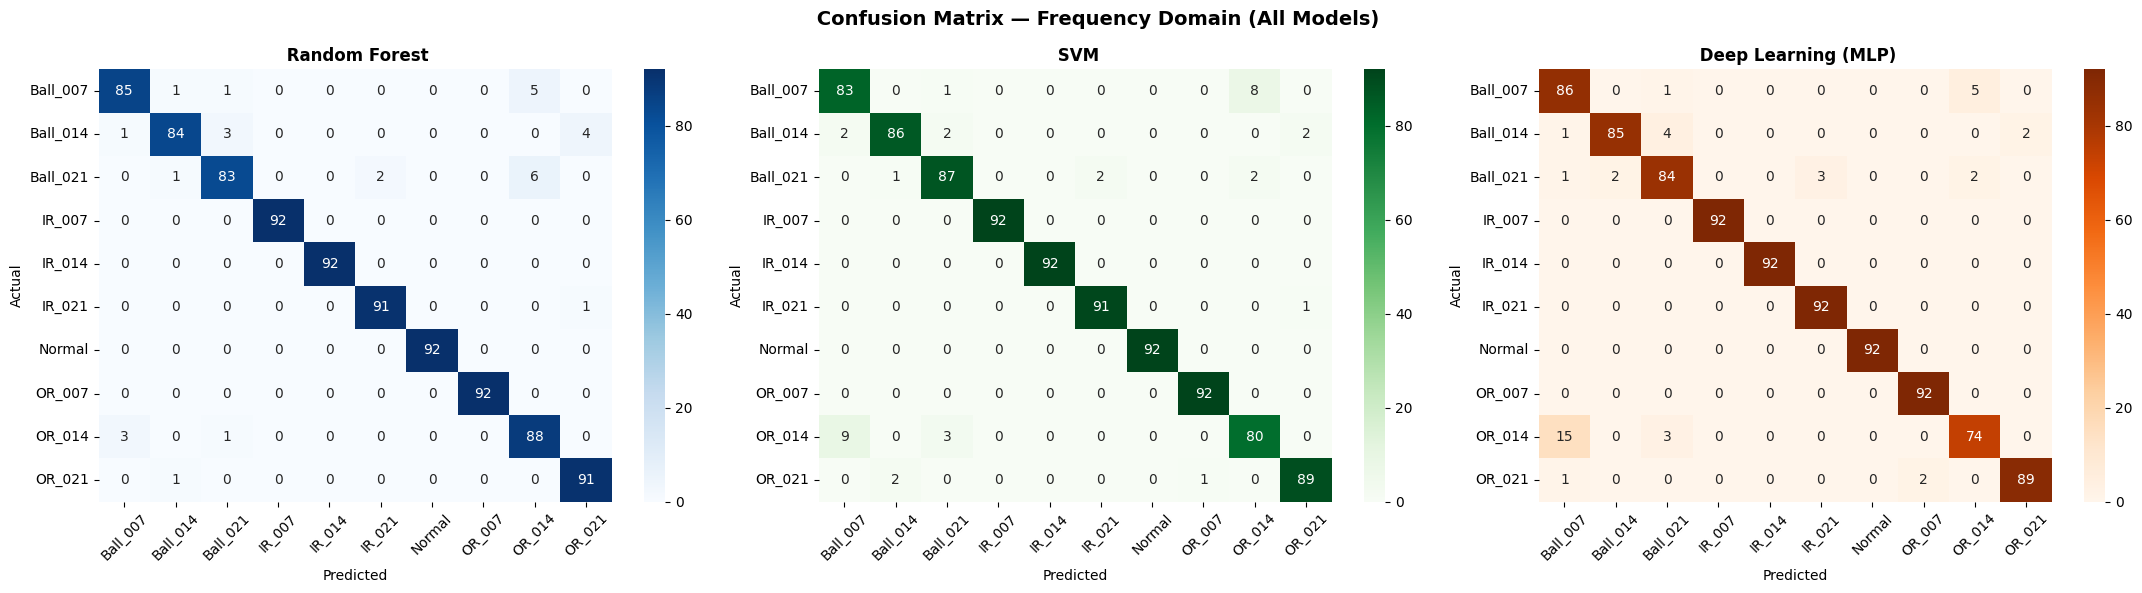


  FREQUENCY DOMAIN RESULTS
   Random Forest : 96.74%
   SVM           : 96.09%
   Deep Learning : 95.43%

  Best : RF


In [ ]:
# Heatmap and Confusion Matrices

# Get Predictions
rf_f_pred  = rf_f.predict(X_test_f)
svm_f_pred = svm_f.predict(X_test_f)
dl_f_pred  = np.argmax(model_freq.predict(X_test_f), axis=1)

# Confusion Matrices
cm_rf_f  = confusion_matrix(y_test_f, rf_f_pred)
cm_svm_f = confusion_matrix(y_test_f, svm_f_pred)
cm_dl_f  = confusion_matrix(y_test_f, dl_f_pred)

# Plot All 3
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, cm, title, cmap in zip(
    axes,
    [cm_rf_f, cm_svm_f, cm_dl_f],
    ['Random Forest', 'SVM', 'Deep Learning (MLP)'],
    ['Blues', 'Greens', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=cmap,
                xticklabels=le_freq.classes_,
                yticklabels=le_freq.classes_,
                ax=ax)
    ax.set_title(f' {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(' Confusion Matrix — Frequency Domain (All Models)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print Summary
print("\n" + "="*40)
print("  FREQUENCY DOMAIN RESULTS")
print("="*40)
print(f"   Random Forest : {rf_f_acc*100:.2f}%")
print(f"   SVM           : {svm_f_acc*100:.2f}%")
print(f"   Deep Learning : {dl_f_acc*100:.2f}%")
print("="*40)
best_f = max({'RF': rf_f_acc, 'SVM': svm_f_acc,
              'DL': dl_f_acc}, key=lambda x: {'RF': rf_f_acc,
              'SVM': svm_f_acc, 'DL': dl_f_acc}[x])
print(f"\n  Best : {best_f}")

**All combined results of this projects**

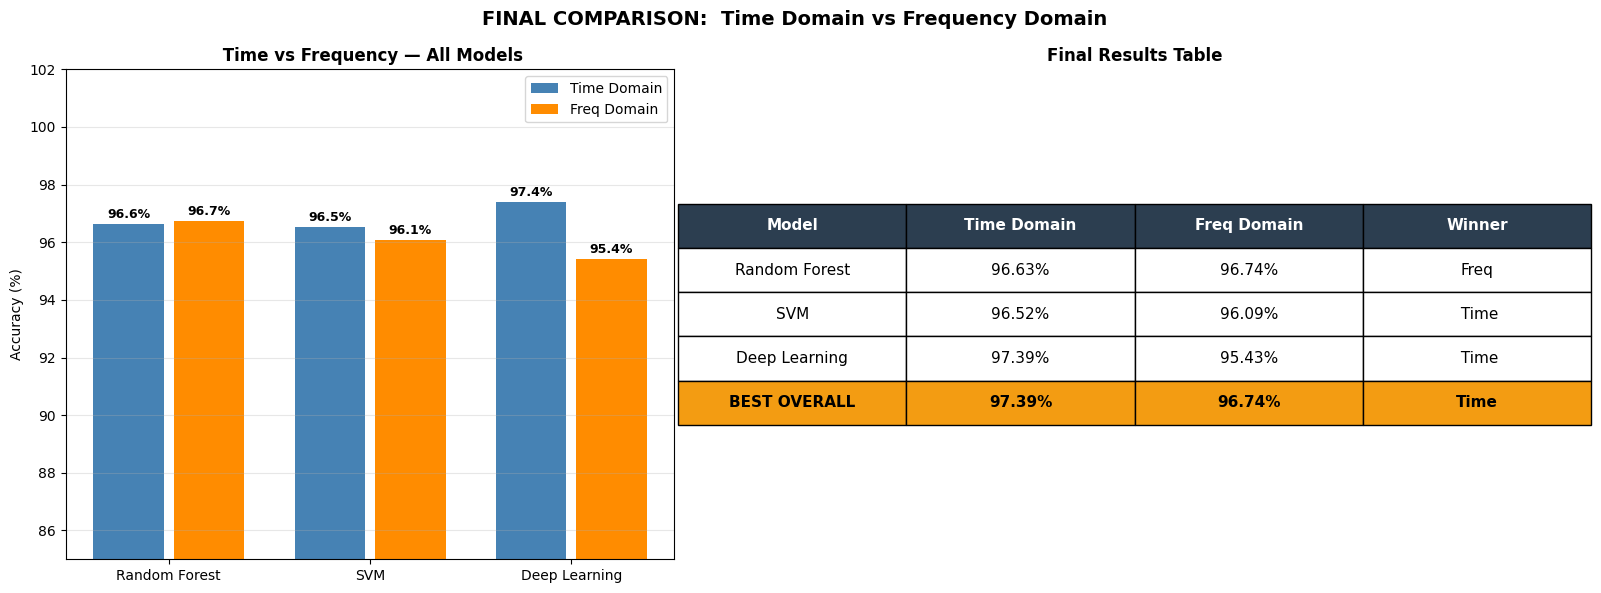


  FINAL PROJECT VERDICT
   Best Time Domain : 97.39%
   Best Freq Domain : 96.74%
---------------------------------------------
  WINNER → TIME DOMAIN (97.39%)
   Reason: WPT on raw signal captures
   impact patterns better than FFT!


In [ ]:
#  All Results
models_names = ['Random Forest', 'SVM', 'Deep Learning']

time_accs = [rf_acc*100,   svm_acc*100,   dl_acc*100]
freq_accs = [rf_f_acc*100, svm_f_acc*100, dl_f_acc*100]

# Bar Chart Comparison
x   = np.arange(len(models_names))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Side by side bars
bars1 = axes[0].bar(x - 0.2, time_accs, 0.35,
                     label='Time Domain', color='steelblue')
bars2 = axes[0].bar(x + 0.2, freq_accs, 0.35,
                     label='Freq Domain', color='darkorange')

axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(85, 102)
axes[0].set_title(' Time vs Frequency — All Models',
                   fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add accuracy numbers on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# Plot 2: Summary table
axes[1].axis('off')
table_data = [
    ['Model', 'Time Domain', 'Freq Domain', 'Winner'],
    ['Random Forest',
     f'{rf_acc*100:.2f}%',
     f'{rf_f_acc*100:.2f}%',
     ' Time' if rf_acc > rf_f_acc else 'Freq'],
    ['SVM',
     f'{svm_acc*100:.2f}%',
     f'{svm_f_acc*100:.2f}%',
     ' Time' if svm_acc > svm_f_acc else 'Freq'],
    ['Deep Learning',
     f'{dl_acc*100:.2f}%',
     f'{dl_f_acc*100:.2f}%',
     ' Time' if dl_acc > dl_f_acc else 'Freq'],
    ['BEST OVERALL',
     f'{max(time_accs):.2f}%',
     f'{max(freq_accs):.2f}%',
     'Time' if max(time_accs) > max(freq_accs) else 'Freq'],
]

table = axes[1].table(cellText=table_data[1:],
                       colLabels=table_data[0],
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.5, 2.5)

# Color header
for j in range(4):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color last row
for j in range(4):
    table[4, j].set_facecolor('#F39C12')
    table[4, j].set_text_props(fontweight='bold')

axes[1].set_title('Final Results Table',
                   fontsize=12, fontweight='bold')

plt.suptitle('FINAL COMPARISON:  Time Domain vs Frequency Domain',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Final Verdict
best_time = max(time_accs)
best_freq = max(freq_accs)

print("\n" + "="*45)
print("  FINAL PROJECT VERDICT")
print("="*45)
print(f"   Best Time Domain : {best_time:.2f}%")
print(f"   Best Freq Domain : {best_freq:.2f}%")
print("-"*45)
if best_time > best_freq:
    print(f"  WINNER → TIME DOMAIN ({best_time:.2f}%)")
    print("   Reason: WPT on raw signal captures")
    print("   impact patterns better than FFT!")
else:
    print(f"  WINNER → FREQUENCY DOMAIN ({best_freq:.2f}%)")
    print("   Reason: FFT reveals fault frequencies")
    print("   that are hidden in time domain!")
print("="*45)